In [75]:
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf 
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
cwd = Path.cwd().resolve()
for p in cwd.parents:
    if (p / '.git').exists():
        %cd {str(p)}
        break

In [56]:
df = pd.read_csv("data/processed/order_delivery_dataset_train.csv")
df = df[df.transit_days > 0]

In [57]:
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['dow'] = df.order_delivered_carrier_date.dt.dayofweek
df['is_within_state'] = df.customer_state == df.seller_state

In [58]:
df.groupby('dow').transit_days.mean()

dow
0     8.996001
1     9.461701
2     9.552405
3    10.002107
4    10.150950
5    11.009826
6     8.854291
Name: transit_days, dtype: float64

In [59]:
df.groupby('is_within_state').transit_days.mean()

is_within_state
False    11.799291
True      5.229239
Name: transit_days, dtype: float64

In [60]:
df.groupby(by = ['dow', 'is_within_state']).transit_days.mean()

dow  is_within_state
0    False              11.170822
     True                4.392110
1    False              11.602806
     True                5.171501
2    False              11.734953
     True                5.196340
3    False              12.214217
     True                5.473484
4    False              12.329609
     True                5.947895
5    False              13.440741
     True                5.912747
6    False              10.424633
     True                4.143264
Name: transit_days, dtype: float64

In [72]:
model = smf.ols('transit_days ~ C(dow) + C(is_within_state) + C(dow) * C(is_within_state)', data = df)
result =model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:           transit_days   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     474.8
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:42:43   Log-Likelihood:            -1.5091e+05
No. Observations:               42787   AIC:                         3.019e+05
Df Residuals:                   42773   BIC:                         3.020e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [62]:
f_test_result = result.f_test(
    """
    C(dow)[T.1]:C(is_within_state)[T.True] = 0, 
    C(dow)[T.2]:C(is_within_state)[T.True] = 0,
    C(dow)[T.3]:C(is_within_state)[T.True] = 0,
    C(dow)[T.4]:C(is_within_state)[T.True] = 0,
    C(dow)[T.5]:C(is_within_state)[T.True] = 0,
    C(dow)[T.6]:C(is_within_state)[T.True] = 0
    """
)
print(f_test_result)

<F test: F=0.8139212283314062, p=0.5588427589340443, df_denom=4.28e+04, df_num=6>


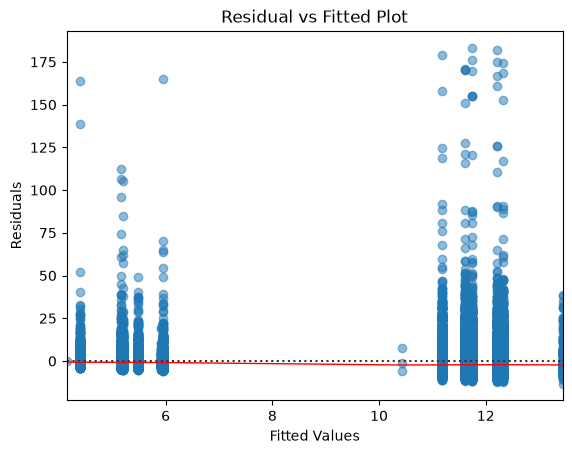

In [63]:
# Extract fitted values and residuals
fitted_values = result.fittedvalues
residuals = result.resid

# Create the residual vs fitted plot
sns.residplot(
    x=fitted_values, 
    y=residuals, 
    lowess=True, 
    scatter_kws={"alpha": 0.5}, 
    line_kws={"color": "red", "lw": 1}
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")
plt.show()

In [64]:
pd.crosstab(index = df['dow'], columns = df['is_within_state'])

is_within_state,False,True
dow,,
0,5885,2780
1,6444,3216
2,5788,2900
3,5075,2479
4,5095,2641
5,325,155
6,3,1


In [73]:
log_model = smf.ols('np.log(1 + transit_days) ~ C(dow) + C(is_within_state) + C(dow) * C(is_within_state)', data = df)
log_result = log_model.fit()
print(log_result.summary())

                               OLS Regression Results                               
Dep. Variable:     np.log(1 + transit_days)   R-squared:                       0.304
Model:                                  OLS   Adj. R-squared:                  0.304
Method:                       Least Squares   F-statistic:                     1440.
Date:                      Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                              14:42:55   Log-Likelihood:                -36232.
No. Observations:                     42787   AIC:                         7.249e+04
Df Residuals:                         42773   BIC:                         7.261e+04
Df Model:                                13                                         
Covariance Type:                  nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

In [68]:
log_f_test_result = log_result.f_test(
    """
    C(dow)[T.1]:C(is_within_state)[T.True] = 0, 
    C(dow)[T.2]:C(is_within_state)[T.True] = 0,
    C(dow)[T.3]:C(is_within_state)[T.True] = 0,
    C(dow)[T.4]:C(is_within_state)[T.True] = 0,
    C(dow)[T.5]:C(is_within_state)[T.True] = 0,
    C(dow)[T.6]:C(is_within_state)[T.True] = 0
    """
)
print(log_f_test_result)

<F test: F=18.899779768236506, p=4.242055467575341e-22, df_denom=4.28e+04, df_num=6>


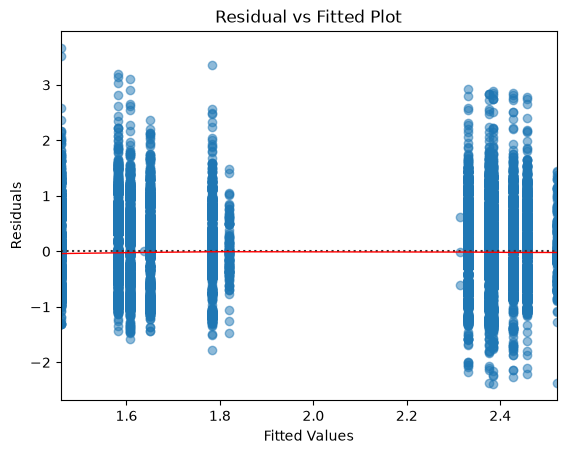

In [69]:
# Extract fitted values and residuals
fitted_values = log_result.fittedvalues
residuals = log_result.resid

# Create the residual vs fitted plot
sns.residplot(
    x=fitted_values, 
    y=residuals, 
    lowess=True, 
    scatter_kws={"alpha": 0.5}, 
    line_kws={"color": "red", "lw": 1}
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")
plt.show()

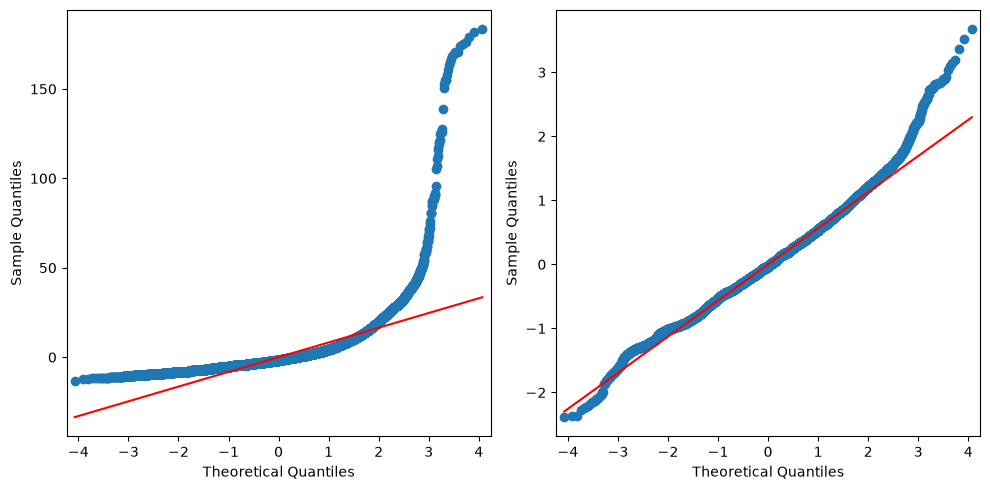

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

sm.qqplot(result.resid, line='s', ax = ax1)
sm.qqplot(log_result.resid, line = 's', ax = ax2)
plt.tight_layout()
plt.show()